In [73]:
import pandas as pd

df = pd.read_csv('../datasets/redmi6.csv', encoding='windows-1252')

In [74]:
df.head()

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful


In [75]:
df['Rating'] = df['Rating'].str.split(' ', expand=True)[0]

In [76]:
df['Rating'].head()

0    4.0
1    3.0
2    3.0
3    5.0
4    2.0
Name: Rating, dtype: object

In [77]:
df

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,
1,vry small size mobile,Raza ji,3.0,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,Vaibhav Patel,3.0,on 18 September 2018,Others,Quite good,7 people found this helpful
3,Value for Money,Amazon Customer,5.0,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful
...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5.0,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\nI...",NaN
276,Mi is best phone,Sunil Soni,4.0,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN
277,Its a OK Phone,D.C.Padhi,3.0,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN
278,Redmi,Mahesh,5.0,on 21 September 2018,Others,I love mi,NaN


In [78]:
df = df[['Rating', 'Comments', 'Category']]

In [79]:
df.count()

Rating      280
Comments    280
Category    280
dtype: int64

In [80]:
df['Comment Categories'] = df['Comments'].iloc[0:0]

df['Comment Categories'].count()

C:\Users\Han\AppData\Local\Temp\ipykernel_1652\1588207541.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Comment Categories'] = df['Comments'].iloc[0:0]


0

In [81]:
df['Comment Categories'].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Comment Categories, dtype: object

In [82]:
import ollama

for i in range(len(df['Comments'])):
    comment = df['Comments'].iloc[i]

    response = ollama.generate(
        model='qwen2.5-coder:latest',  
        prompt=f"Categorize {comment}, make you return only: Very Negative, Negative, Neutral, Positive, Very Positive, without any explanation."
    )

    print(f"i: {i}, response: {response['response']}")

    df.loc[i, 'Comment Categories'] = response['response'].strip()

i: 0, response: Positive
i: 1, response: Negative
i: 2, response: Positive
i: 3, response: Positive
i: 4, response: Negative
i: 5, response: Positive
i: 6, response: Positive
i: 7, response: Negative
i: 8, response: Neutral
i: 9, response: Negative
i: 10, response: Positive
i: 11, response: Negative
i: 12, response: Positive
i: 13, response: Positive
i: 14, response: Negative
i: 15, response: Positive
i: 16, response: Positive
i: 17, response: Negative
i: 18, response: Neutral
i: 19, response: Negative
i: 20, response: Positive
i: 21, response: Positive
i: 22, response: Negative
i: 23, response: Negative
i: 24, response: Positive
i: 25, response: **Category:** Negative  
**Reasoning:** The review is overwhelmingly negative due to the lack of features mentioned in the pros section. Even though there are some positive comments about the display and battery life, they do not outweigh the significant issue with the front camera quality. The reviewer's tone indicates dissatisfaction, and th

In [83]:
df = df[df['Comment Categories'].isin(['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'])]

In [84]:
df.count()

Rating                276
Comments              276
Category              276
Comment Categories    276
dtype: int64

In [85]:
df['Rating'] = df['Rating'].astype(float)

In [86]:
df['Rating Categories'] = df['Rating'].map({5.0: 'Very Positive', 4.0: 'Positive', 3.0: 'Neutral', 2.0: 'Negative', 1.0: 'Very Negative'}) 

In [87]:
df.head() 

,Rating,Comments,Category,Comment Categories,Rating Categories
0,4.0,Another Midrange killer Smartphone by Xiaomi\n...,Display,Positive,Positive
1,3.0,All ok but vry small size mobile,Others,Negative,Neutral
2,3.0,Quite good,Others,Positive,Neutral
3,5.0,Redmi has always have been the the king of bud...,Display,Positive,Very Positive
4,2.0,worst product from MI. I am a hardcore fan of ...,Others,Negative,Negative


In [88]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

               Rating Categories Count  Comment Categories Count
Very Positive                      150                        13
Positive                            48                       145
Very Negative                       42                        22
Neutral                             27                        30
Negative                             9                        66


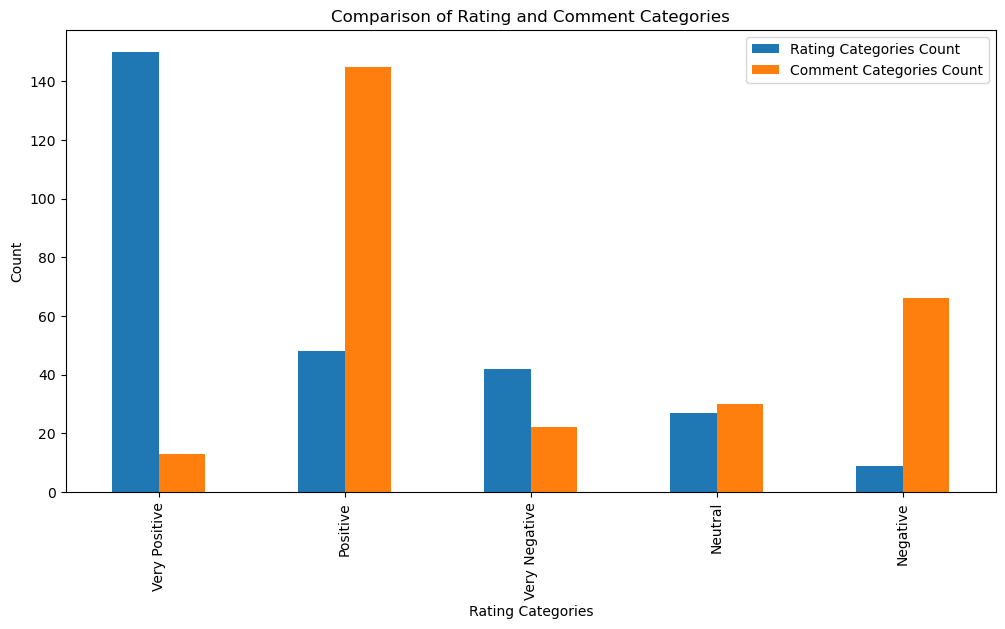

In [89]:
import matplotlib.pyplot as plt

# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

In [90]:
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 204


In [91]:
df['Rating Categories'] = df['Rating Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'}) 

In [92]:
df['Comment Categories'] = df['Comment Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'}) 

In [93]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

          Rating Categories Count  Comment Categories Count
Positive                      198                       158
Negative                       51                        88
Neutral                        27                        30


In [94]:
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 79


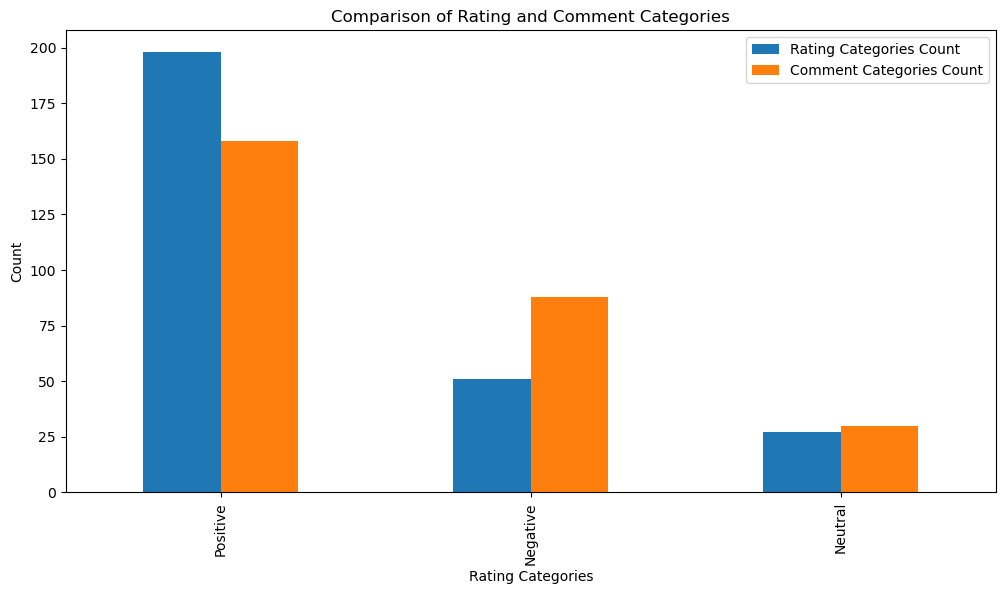

In [95]:
# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

In [96]:
df

,Rating,Comments,Category,Comment Categories,Rating Categories
0,4.0,Another Midrange killer Smartphone by Xiaomi\n...,Display,Positive,Positive
1,3.0,All ok but vry small size mobile,Others,Negative,Neutral
2,3.0,Quite good,Others,Positive,Neutral
3,5.0,Redmi has always have been the the king of bud...,Display,Positive,Positive
4,2.0,worst product from MI. I am a hardcore fan of ...,Others,Negative,Negative
...,...,...,...,...,...
275,5.0,"I like This Phone, Awesome look and design.\nI...",Others,Positive,Positive
276,4.0,Product is avasome but invoice is note include...,Others,Negative,Positive
277,3.0,"Redmi Note4, Note5, now 6pro..It seems the old...",Battery,Negative,Neutral
278,5.0,I love mi,Others,Positive,Positive


In [97]:
nlp_df = df[['Category', 'Comments', 'Comment Categories']]

In [98]:
nlp_df

,Category,Comments,Comment Categories
0,Display,Another Midrange killer Smartphone by Xiaomi\n...,Positive
1,Others,All ok but vry small size mobile,Negative
2,Others,Quite good,Positive
3,Display,Redmi has always have been the the king of bud...,Positive
4,Others,worst product from MI. I am a hardcore fan of ...,Negative
...,...,...,...
275,Others,"I like This Phone, Awesome look and design.\nI...",Positive
276,Others,Product is avasome but invoice is note include...,Negative
277,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",Negative
278,Others,I love mi,Positive


In [99]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(nlp_df, test_size=0.2, random_state=42)

In [100]:
# Get total unique words in the training set
all_words = nlp_df['Comments'].str.lower().str.split().apply(lambda x: len(set(x)))
print(f'All unique words in training set: {all_words.sum()}')

All unique words in training set: 5359


In [101]:
from tensorflow.keras.preprocessing.text import Tokenizer
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_lem(text):
    tokens_stem = text.split()
    stemmed_tokens = [stemmer.stem(token) for token in tokens_stem]
    tokens_lem = ' '.join(stemmed_tokens).split()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens_lem]
    return ' '.join(lemmatized_tokens)

tokenizer = Tokenizer(num_words=5358, oov_token='<OOV>')

responses = [stem_lem(response) for response in train_df["Comments"]]

tokenizer.fit_on_texts(responses)

print(f"Tokenizer vocabulary size: {len(tokenizer.word_index)}")
print(tokenizer.texts_to_sequences([responses[0]]), responses[0])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Han\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Han\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Tokenizer vocabulary size: 1057
[[132, 143, 5, 589, 4, 50, 88, 2, 143, 89, 67, 144, 161, 196, 69, 90, 590, 91, 10, 2, 292, 22, 51, 25, 23, 7, 162, 591, 75, 145, 25, 146, 15, 147, 24, 293, 11, 592, 294, 593, 594, 23, 67, 106, 6, 295, 35]] overal realli good.fingerprint and face unlock is realli fast.no lag problem while work or gaming. back camera is awesome. but,if you are a selfi lover so then you should not go with this. it contain ir blaster,ther are no other phone provid that.


In [102]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen=50
def get_sequences(tokenizer, responses):
    sequences = tokenizer.texts_to_sequences(responses)
    padded = pad_sequences(sequences, truncating = 'post', padding='post', maxlen=maxlen)
    return padded

padded_train_seq = get_sequences(tokenizer, responses)

padded_train_seq

array([[132, 143,   5, ...,   0,   0,   0],
       [ 13, 107,   3, ...,   0,   0,   0],
       [ 67,  80, 133, ...,   0,   0,   0],
       ...,
       [ 45,  43,  74, ...,   0,   0,   0],
       [ 28,  31,  29, ...,   0,   0,   0],
       [395, 370,  33, ...,   0,   0,   0]])

In [103]:
import numpy as np

labels = train_df['Comment Categories']

classes = set(labels)

class_to_index = dict((c,i) for i, c in enumerate(classes))
index_to_class = dict((v,k) for k, v in class_to_index.items())
names_to_ids = lambda labels: np.array([class_to_index.get(x) for x in labels])
train_labels = names_to_ids(labels)

print(classes)
print(class_to_index)
print(index_to_class)
print(train_labels)

{'Negative', 'Neutral', 'Positive'}
{'Negative': 0, 'Neutral': 1, 'Positive': 2}
{0: 'Negative', 1: 'Neutral', 2: 'Positive'}
[2 2 2 2 1 2 2 1 2 0 0 0 2 2 0 0 2 2 1 0 1 2 2 2 0 1 2 0 2 2 2 2 0 2 2 2 0
 1 2 2 2 0 0 2 2 2 0 2 2 2 2 1 0 0 2 2 0 0 2 2 2 0 2 0 2 2 2 2 0 2 1 2 2 1
 2 2 2 2 2 2 0 2 0 2 1 2 0 2 2 0 0 2 2 2 2 2 2 1 2 0 2 1 1 0 0 0 2 2 2 0 2
 0 2 1 0 1 2 0 0 2 0 2 2 0 2 2 0 2 2 2 2 0 2 0 2 2 2 1 2 2 2 0 1 0 2 2 1 2
 2 0 0 0 0 2 2 2 0 1 2 0 0 1 2 2 0 2 2 1 0 2 1 2 2 0 1 0 2 2 2 2 2 2 0 2 0
 2 1 0 2 0 1 0 2 2 0 2 2 2 0 2 1 0 2 2 2 0 2 2 2 2 2 2 2 0 2 2 0 2 0 0]


In [104]:
from tensorflow import keras

model = keras.models.Sequential([
keras.layers.Embedding(5358,16),
keras.layers.Bidirectional(keras.layers.LSTM(20, return_sequences=True)),
keras.layers.Bidirectional(keras.layers.LSTM(20)),
keras.layers.Dense(6, activation='softmax')
])
model.compile(
     loss='sparse_categorical_crossentropy',
     optimizer='adam',
     metrics=['accuracy']
)

In [105]:
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)

In [106]:
val_responses = val_df['Comments']
val_labels = val_df['Comment Categories']

val_responses = [stem_lem(val_response) for val_response in val_responses]

val_seq = get_sequences(tokenizer, val_responses)
val_labels= names_to_ids(val_labels)
h = model.fit(
     padded_train_seq, train_labels,
     validation_data=(val_seq, val_labels),
     epochs=20,
     callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)]
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 339ms/step - accuracy: 0.3923 - loss: 1.7460 - val_accuracy: 0.5714 - val_loss: 1.5972
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5807 - loss: 1.4915 - val_accuracy: 0.5714 - val_loss: 1.2760
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6183 - loss: 1.1446 - val_accuracy: 0.5714 - val_loss: 1.1122


In [107]:
test_responses = test_df['Comments']
test_labels = test_df['Comment Categories']

test_responses = [stem_lem(response) for response in test_responses]

test_seq = get_sequences(tokenizer, test_responses)
test_labels=names_to_ids(test_labels)
model.evaluate(test_seq, test_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4643 - loss: 1.1346


[1.1346490383148193, 0.4642857015132904]

In [108]:
import random

i = random.randint(0,len(test_labels)-1)
print('Comment:', test_responses[i])
print('Comment Categories:', index_to_class[test_labels[i]])
p = model.predict(np.expand_dims(test_seq[i], axis=0))[0]
print(test_seq[i])
pred_class=index_to_class[np.argmax(p).astype('uint8')]
print('Predicted Comment Category: ', pred_class)

Comment: nice
Comment Categories: Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
[28  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]
Predicted Comment Category:  Positive


In [109]:
comment = 'redmi6 is great'
sequence = tokenizer.texts_to_sequences([comment])
paddedSequence = pad_sequences(sequence, truncating = 'post', padding='post', maxlen=maxlen)
p = model.predict(np.expand_dims(paddedSequence[0], axis=0))[0]
pred_class=index_to_class[np.argmax(p).astype('uint8')]
print('Comment:', comment)
print('Predicted Comment Category: ', pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Comment: redmi6 is great
Predicted Comment Category:  Positive


In [110]:
nlp_df['New Comment Categories'] = nlp_df['Comment Categories'].iloc[0:0]

C:\Users\Han\AppData\Local\Temp\ipykernel_1652\2557852972.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nlp_df['New Comment Categories'] = nlp_df['Comment Categories'].iloc[0:0]


In [111]:
nlp_df

,Category,Comments,Comment Categories,New Comment Categories
0,Display,Another Midrange killer Smartphone by Xiaomi\n...,Positive,NaN
1,Others,All ok but vry small size mobile,Negative,NaN
2,Others,Quite good,Positive,NaN
3,Display,Redmi has always have been the the king of bud...,Positive,NaN
4,Others,worst product from MI. I am a hardcore fan of ...,Negative,NaN
...,...,...,...,...
275,Others,"I like This Phone, Awesome look and design.\nI...",Positive,NaN
276,Others,Product is avasome but invoice is note include...,Negative,NaN
277,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",Negative,NaN
278,Others,I love mi,Positive,NaN


In [125]:
for i in range(len(nlp_df['Comments'])):
    comment = df['Comments'].iloc[i]
    sequence = tokenizer.texts_to_sequences([comment])
    paddedSequence = pad_sequences(sequence, truncating = 'post', padding='post', maxlen=maxlen)
    p = model.predict(np.expand_dims(paddedSequence[0], axis=0))[0]
    pred_class=index_to_class[np.argmax(p).astype('uint8')]
    print(pred_class)
    nlp_df.loc[i, 'New Comment Categories'] = pred_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Positive
1/1 ━━━━━━━━━

C:\Users\Han\AppData\Local\Temp\ipykernel_1652\3076982760.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nlp_df.loc[i, 'New Comment Categories'] = pred_class


Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Positive
1/1 

In [126]:
nlp_df

,Category,Comments,Comment Categories,New Comment Categories
0,Display,Another Midrange killer Smartphone by Xiaomi\n...,Positive,Positive
1,Others,All ok but vry small size mobile,Negative,Positive
2,Others,Quite good,Positive,Positive
3,Display,Redmi has always have been the the king of bud...,Positive,Positive
4,Others,worst product from MI. I am a hardcore fan of ...,Negative,Positive
...,...,...,...,...
279,Camera,Same old configurations with higher price.\nNo...,Negative,NaN
25,NaN,NaN,NaN,Positive
183,NaN,NaN,NaN,Positive
185,NaN,NaN,NaN,Positive


In [115]:
pivot_table = nlp_df.pivot_table(index='Category', columns='New Comment Categories', aggfunc='size', fill_value=0)

# Display the pivot table
pivot_table.plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Visualization by Category and New Comment Categories')
plt.show()

TypeError: no numeric data to plot